In [1]:
import glob
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from matplotlib.animation import FuncAnimation
import math
import time

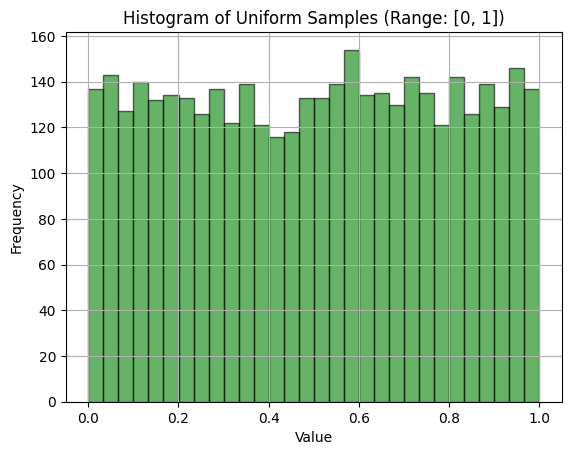

In [2]:
batch_size = 4000
# Generate sample points from a Uniform distribution (range: [low, high])
uniform_samples = np.random.uniform(low=0, high=1, size=batch_size).astype(np.float32)
uniform_samples = torch.tensor(uniform_samples).numpy()

# Plot Histogram
plt.hist(uniform_samples, bins=30, alpha=0.6, color='green', edgecolor='black')
plt.title('Histogram of Uniform Samples (Range: [0, 1])')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

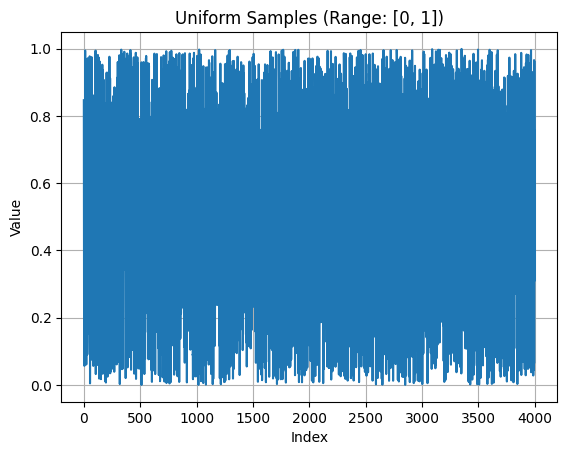

In [3]:
plt.plot(uniform_samples)
plt.title('Uniform Samples (Range: [0, 1])')
plt.xlabel('Index')
plt.ylabel('Value')
plt.grid(True)
plt.show()

Text(0.5, 0, 'Value')

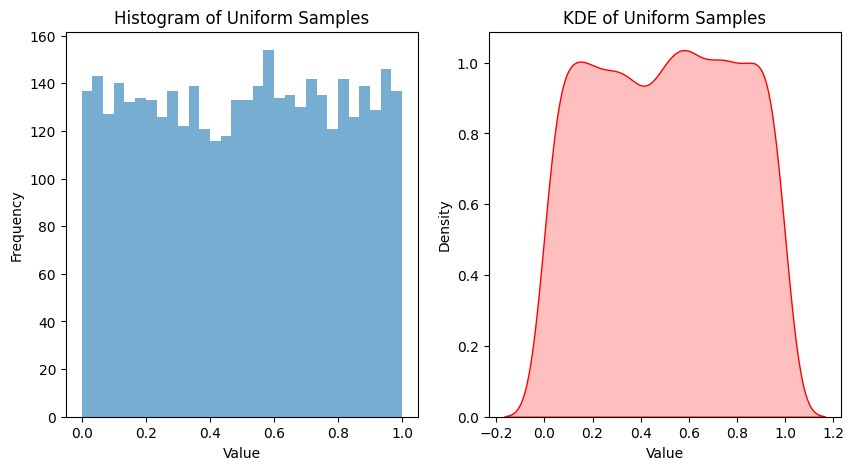

In [4]:
# Plot Histogram
plt.figure(figsize=(10, 5))

# Subplot 1: Histogram
plt.subplot(1, 2, 1)
plt.hist(uniform_samples, bins=30, alpha=0.6)
plt.title('Histogram of Uniform Samples')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Subplot 2: Kernel Density Estimate (KDE)
plt.subplot(1, 2, 2)
sns.kdeplot(uniform_samples, color='red', fill=True)
plt.title('KDE of Uniform Samples')
plt.xlabel('Value')

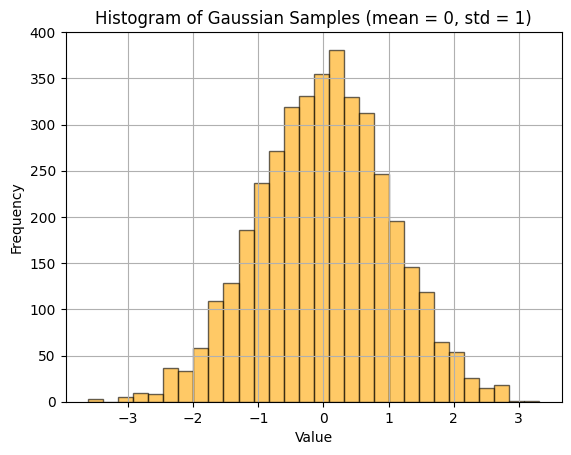

In [5]:
# Step 2: Generate 400 sample points from a Gaussian distribution (mean=0, std=1)
# gaussian_samples = np.random.normal(loc=0, scale=1, size=400).astype(np.float32)
gaussian_samples = norm.ppf(uniform_samples)
gaussian_samples = torch.tensor(gaussian_samples).numpy()

# Plot Histogram
plt.hist(gaussian_samples, bins=30, alpha=0.6, color='orange', edgecolor='black')
plt.title('Histogram of Gaussian Samples (mean = 0, std = 1)')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

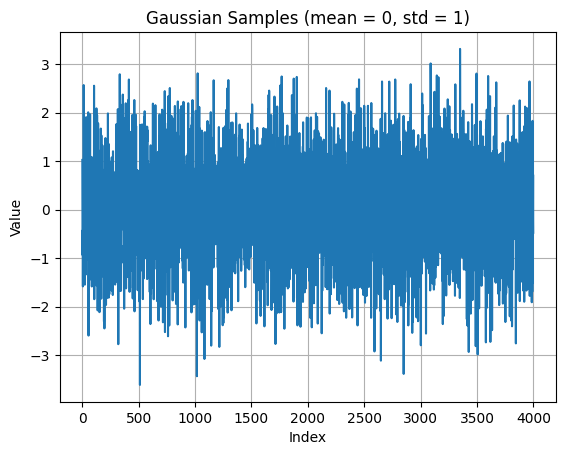

In [6]:
plt.plot(gaussian_samples)
plt.title('Gaussian Samples (mean = 0, std = 1)')
plt.xlabel('Index')
plt.ylabel('Value')
plt.grid(True)
plt.show()

Text(0.5, 0, 'Value')

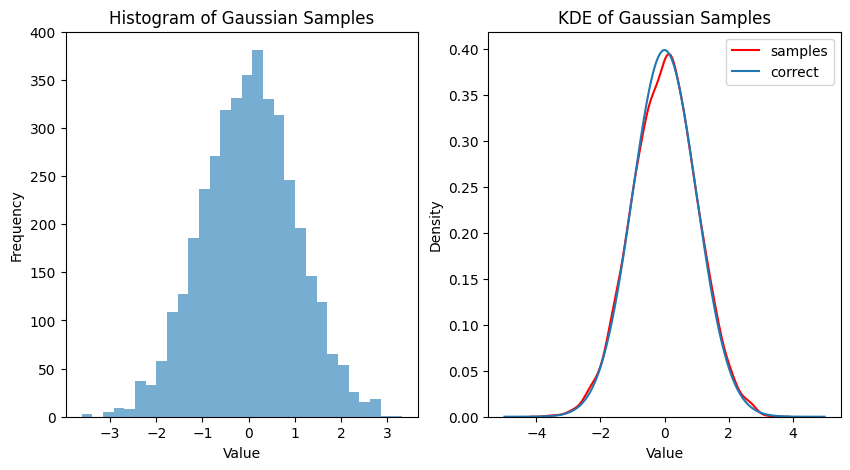

In [7]:
# Plot Histogram
plt.figure(figsize=(10, 5))

# Subplot 1: Histogram
plt.subplot(1, 2, 1)
plt.hist(gaussian_samples, bins=30, alpha=0.6)
plt.title('Histogram of Gaussian Samples')
plt.xlabel('Value')
plt.ylabel('Frequency')


# Subplot 2: Kernel Density Estimate (KDE)
plt.subplot(1, 2, 2)
sns.kdeplot(gaussian_samples, color='red',label='samples')
# Mean = 0, SD = 1.
x_axis = np.arange(-5, 5, 0.0005)
plt.plot(x_axis, norm.pdf(x_axis,0,1), label = 'correct')
plt.legend()
plt.title('KDE of Gaussian Samples')
plt.xlabel('Value')

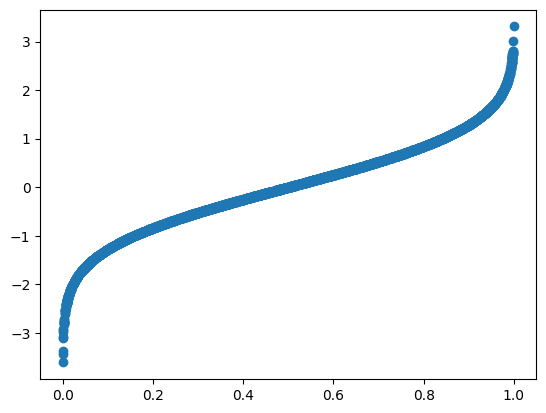

In [8]:
plt.scatter(uniform_samples, gaussian_samples)

In [9]:
uniform_samples = torch.tensor(uniform_samples).unsqueeze(1)
gaussian_samples = torch.tensor(gaussian_samples).unsqueeze(1)

In [10]:
class FNN(nn.Module):
    def __init__(self):
        super(FNN, self).__init__()
        self.fc1 = nn.Linear(1, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 64)
        self.fc4 = nn.Linear(64, 64)
        self.fc5 = nn.Linear(64, 64)
        self.fc6 = nn.Linear(64, 1)
        self.tanh = nn.Tanh()

    def forward(self, x):
        x = self.tanh(self.fc1(x))
        x = self.tanh(self.fc2(x))
        x = self.tanh(self.fc3(x))
        x = self.tanh(self.fc4(x))
        x = self.tanh(self.fc5(x))
        return self.fc6(x)

In [11]:
# Function to compute moments (mean, variance, skewness, kurtosis, and 5th moment)
def compute_moments(samples):
    mean = torch.mean(samples)
    variance = torch.var(samples, unbiased=False)  # Population variance
    skewness = torch.mean(((samples - mean) ** 3)) / (variance ** 1.5)
    kurtosis = torch.mean(((samples - mean) ** 4)) / (variance ** 2) - 3
    fifth_moment = torch.mean((samples - mean) ** 5)
    return mean, variance, skewness, kurtosis, fifth_moment

In [12]:
def compute_mean(samples):
    mean = torch.mean(samples)
    return mean

In [13]:
def compute_variance(samples):
    variance = torch.var(samples, unbiased=False)
    return variance

In [14]:
# Initialize the neural network
model = FNN()

In [15]:
class Model:
    def __init__(self, net, device="cpu"):
        self.net = net
        self.device = device
        self.iter = 0

        # Adaptive weights for AW method
        self.x_mean = None
        self.x_variance = None

        # Metrics storage
        self.mean_loss_list = []
        self.variance_loss_list = []
        self.total_loss_list = []
        self.epoch_list = []

    def train_U(self, x):
        return self.net(x)

    def predict_U(self, x):
        with torch.no_grad():
            return self.train_U(x)

    def baseline_loss(self, outputs):
        mean_loss = (self.compute_mean(outputs) - 0) ** 2  # Mean of standard normal distribution is 0
        variance_loss = (self.compute_variance(outputs) - 1) ** 2  # Variance is 1
        total_loss = mean_loss + 2 * variance_loss
        return mean_loss, variance_loss, total_loss

    def likelihood_loss(self, mean_loss, variance_loss):
        loss = torch.reciprocal(2. * self.x_mean ** 2) * mean_loss.detach() + \
               torch.reciprocal(2. * self.x_variance ** 2) * variance_loss.detach() + \
               torch.log(self.x_mean * self.x_variance)
        return loss

    def true_loss(self, mean_loss, variance_loss):
        return torch.reciprocal(2. * self.x_mean.detach() ** 2) * mean_loss + \
               torch.reciprocal(2. * self.x_variance.detach() ** 2) * variance_loss

    def compute_mean(self, outputs):
        return torch.mean(outputs)

    def compute_variance(self, outputs):
        return torch.var(outputs)

    def run_baseline(self, num_epochs=10000, save_interval=10):
        optimizer = optim.Adam(self.net.parameters(), lr=0.001)

        for epoch in range(num_epochs):
            optimizer.zero_grad()

            # Generate uniform input
            uni_input = np.random.uniform(low=0, high=1, size=batch_size).astype(np.float32)
            uni_input = torch.tensor(uni_input).unsqueeze(1).to(self.device)

            # Forward pass
            outputs = self.train_U(uni_input)

            # Compute losses
            mean_loss, variance_loss, total_loss = self.baseline_loss(outputs)

            # Backward pass and optimization
            total_loss.backward()
            optimizer.step()

            # Store metrics
            self.mean_loss_list.append(mean_loss.item())
            self.variance_loss_list.append(variance_loss.item())
            self.total_loss_list.append(total_loss.item())
            self.epoch_list.append(epoch + 1)

            print(f'Epoch [{epoch + 1}/{num_epochs}], Mean Loss: {mean_loss.item():.4f}, '
                  f'Variance Loss: {variance_loss.item():.4f}, Total Loss: {total_loss.item():.4f}')


            # Early stopping
            if mean_loss <= 0.0001 and variance_loss <= 0.0001:
                print(f"Early stopping at epoch {epoch + 1}")
                torch.save(self.net.state_dict(), f"model_epoch_{epoch + 1}.pt")
                break

    def run_AW(self, num_epochs=10000, save_interval=10):
        self.x_mean = nn.Parameter(torch.tensor(2.0, requires_grad=True))
        self.x_variance = nn.Parameter(torch.tensor(2.0, requires_grad=True))

        optimizer_net = optim.Adam(self.net.parameters(), lr=0.001)
        optimizer_weights = optim.Adam([self.x_mean, self.x_variance], lr=0.001)

        for epoch in range(num_epochs):
            optimizer_net.zero_grad()

            # Generate uniform input
            uni_input = np.random.uniform(low=0, high=1, size=batch_size).astype(np.float32)
            uni_input = torch.tensor(uni_input).unsqueeze(1).to(self.device)

            # Forward pass
            outputs = self.train_U(uni_input)

            # Compute losses
            mean_loss = (self.compute_mean(outputs) - 0) ** 2
            variance_loss = (self.compute_variance(outputs) - 1) ** 2
            total_loss = self.true_loss(mean_loss, variance_loss)

            # Backward pass and optimization for network
            total_loss.backward()
            optimizer_net.step()

            # Update adaptive weights
            optimizer_weights.zero_grad()
            likelihood = self.likelihood_loss(mean_loss, variance_loss)
            likelihood.backward()
            optimizer_weights.step()

            # Store metrics
            self.mean_loss_list.append(mean_loss.item())
            self.variance_loss_list.append(variance_loss.item())
            self.total_loss_list.append(total_loss.item())
            self.epoch_list.append(epoch + 1)

            print(f'Epoch [{epoch + 1}/{num_epochs}], Mean Loss: {mean_loss.item():.4f}, '
                  f'Variance Loss: {variance_loss.item():.4f}, Total Loss: {total_loss.item():.4f}')


            # Early stopping
            if mean_loss <= 0.0001 and variance_loss <= 0.0001:
                print(f"Early stopping at epoch {epoch + 1}")
                torch.save(self.net.state_dict(), f"model_epoch_{epoch + 1}.pt")
                break

    def train(self, model_type=0):
        start_time = time.time()
        if model_type == 0:
            self.run_baseline()
        elif model_type == 1:
            self.run_AW()
        elapsed_time = time.time() - start_time
        print(f"Training completed in {elapsed_time:.2f} seconds.")


In [16]:
AWmodel = Model(net=model)

In [17]:
model_type = 1

In [18]:
AWmodel.train()

Epoch [1/10000], Mean Loss: 0.0034, Variance Loss: 0.9998, Total Loss: 2.0030
Epoch [2/10000], Mean Loss: 0.0008, Variance Loss: 0.9995, Total Loss: 1.9998
Epoch [3/10000], Mean Loss: 0.0026, Variance Loss: 0.9990, Total Loss: 2.0007
Epoch [4/10000], Mean Loss: 0.0011, Variance Loss: 0.9985, Total Loss: 1.9980
Epoch [5/10000], Mean Loss: 0.0000, Variance Loss: 0.9978, Total Loss: 1.9955
Epoch [6/10000], Mean Loss: 0.0004, Variance Loss: 0.9964, Total Loss: 1.9932
Epoch [7/10000], Mean Loss: 0.0007, Variance Loss: 0.9942, Total Loss: 1.9891
Epoch [8/10000], Mean Loss: 0.0002, Variance Loss: 0.9904, Total Loss: 1.9809
Epoch [9/10000], Mean Loss: 0.0000, Variance Loss: 0.9841, Total Loss: 1.9682
Epoch [10/10000], Mean Loss: 0.0009, Variance Loss: 0.9749, Total Loss: 1.9507
Model saved at epoch 10
Epoch [11/10000], Mean Loss: 0.0027, Variance Loss: 0.9609, Total Loss: 1.9245
Epoch [12/10000], Mean Loss: 0.0054, Variance Loss: 0.9385, Total Loss: 1.8824
Epoch [13/10000], Mean Loss: 0.0056, 

In [20]:
def draw_loss(model):
    ### Plotting the training and the generalization error
    fig = plt.figure(1)
    ax = fig.add_axes([0.15, 0.15, 0.75, 0.75])
    plt.title("Error plot",fontsize=15) 
    plt.yscale('log')
    plt.plot(model.epoch_list, model.total_loss_list,'r',label='Training error')
    plt.xlabel(r'Training times $n$',fontsize=15)
    plt.ylabel(r'$l_2$',fontsize=15)
    plt.legend(frameon=False,fontsize=15)

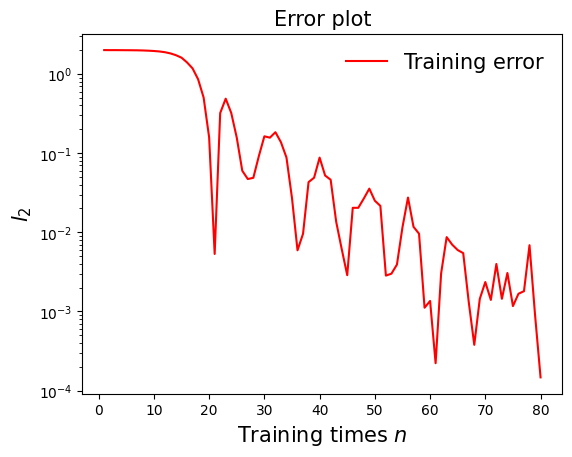

In [21]:
draw_loss(AWmodel)

In [22]:
def draw_errors(model):
    ### Plotting the training and the generalization error
    fig = plt.figure(1)
    ax = fig.add_axes([0.15, 0.15, 0.75, 0.75])
    plt.title("Error plot for loss functions w/o coeff",fontsize=15)
    plt.yscale('log')
    plt.plot(model.epoch_list, model.total_loss_list,'k',label='Training error')

    plt.plot(model.epoch_list, model.mean_loss_list,'r',label='mean error')

    plt.plot(model.epoch_list, model.variance_loss_list,'b',label='variance error')

    plt.xlabel(r'Training times $n$',fontsize=15)
    plt.ylabel(r'$l_2$',fontsize=15)
    plt.legend(frameon=False,fontsize=15, bbox_to_anchor=(1.1, 1.05))

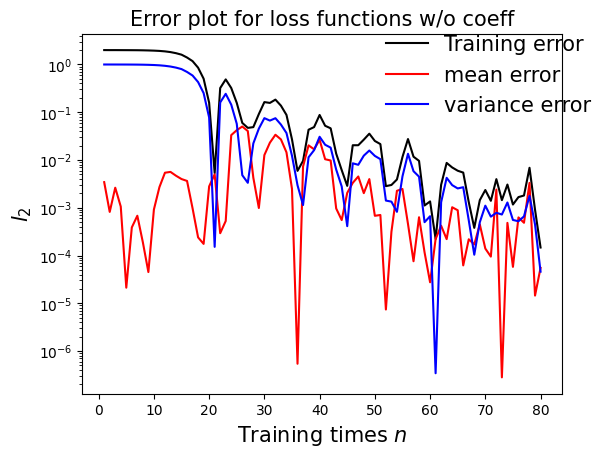

In [23]:
draw_errors(AWmodel)

In [26]:
from matplotlib.animation import FuncAnimation

# Set the input for testing the transformation
input_test = torch.tensor(np.linspace(0, 1, batch_size).astype(np.float32)).unsqueeze(1)
uniform_samples_np = uniform_samples.numpy()
gaussian_samples_np = gaussian_samples.numpy()

In [27]:
# Test the transformation from final model
with torch.no_grad():
    transformed_samples = model(input_test)


# Convert tensors to numpy for visualization
transformed_samples_np = transformed_samples.numpy()

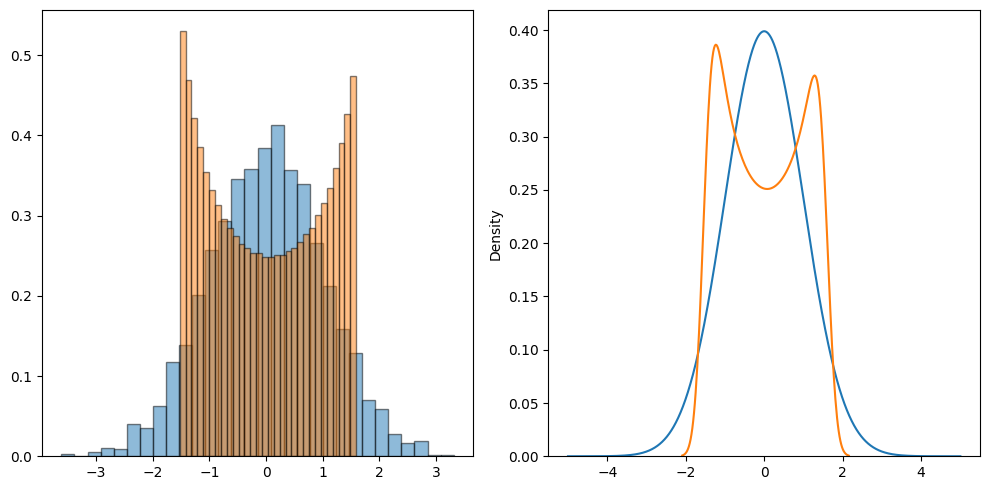

In [28]:
# Step 7: Plot the original and transformed distributions
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.hist(gaussian_samples_np, bins=30, alpha=0.5, density=True, edgecolor='black')
plt.hist(transformed_samples_np, bins=30, alpha=0.5, density=True, edgecolor='black')
# plt.title('Gaussian vs Transformed Distribution')
# plt.legend()

plt.subplot(1, 2, 2)
# Gaussian distribution with Mean = 0, SD = 1.
x_axis = np.arange(-5, 5, 0.0005)
plt.plot(x_axis, norm.pdf(x_axis,0,1))
sns.kdeplot(transformed_samples.cpu().reshape(batch_size))
# plt.title('Gaussian vs Transformed Distribution')

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Frequency')

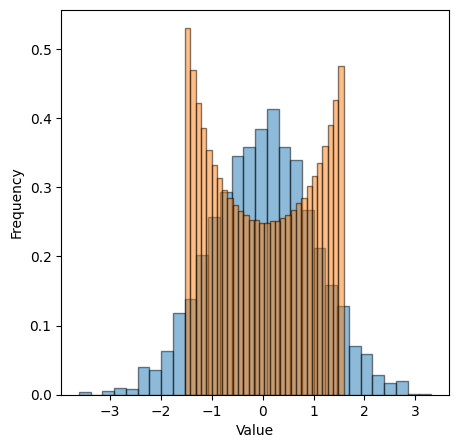

In [29]:
plt.figure(figsize=(5, 5))
plt.hist(gaussian_samples_np, bins=30, alpha=0.5, density=True, edgecolor='black')
plt.hist(transformed_samples_np, bins=30, alpha=0.5, density=True, edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Frequency')
# plt.title('Gaussian vs Transformed Distribution')

Text(0.5, 0, 'Value')

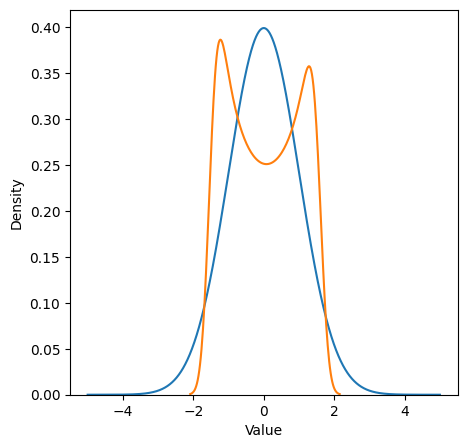

In [30]:
plt.figure(figsize=(5, 5))
# Normal distribution with Mean = 0, SD = 1.
x_axis = np.arange(-5, 5, 0.0005)
plt.plot(x_axis, norm.pdf(x_axis,0,1))
sns.kdeplot(transformed_samples.cpu().reshape(batch_size))
# plt.title('Gaussian vs Transformed Distribution')
plt.xlabel('Value')
# plt.ylim(0, 0.71)